# **Feature Engineering & Modeling**

**Mô tả:** 
1. **Feature Engineering** – Tạo thêm các đặc trưng mới từ dữ liệu đã tiền xử lý
2. **Huấn luyện các mô hình** – CatBoost, QDA, SVM, LightGBM (DART / GOSS / GBDT)
3. **Tổng kết & so sánh** – Bảng so sánh hiệu suất các mô hình

---

## 1. Khai báo thư viện cần thiết

In [1]:
# Thư viện cơ bản 
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Tiền xử lý / Pipeline 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from category_encoders import TargetEncoder

# Đánh giá mô hình 
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    classification_report, confusion_matrix, roc_curve,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Mô hình 
import optuna
from catboost import CatBoostClassifier, Pool
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.svm import SVC
import lightgbm as lgb
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from scipy.stats import loguniform


# Tối ưu siêu tham số
from sklearn.model_selection import RandomizedSearchCV

# Cài đặt hiển thị 
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

## 2. Đọc dữ liệu đã tiền xử lý

In [2]:
# Đường dẫn dữ liệu 
DATA_DIR = 'data/processed/'

# Đọc tập huấn luyện / validation / test
X_train = pd.read_csv(DATA_DIR + 'X_train.csv')
X_val   = pd.read_csv(DATA_DIR + 'X_val.csv')
y_train = pd.read_csv(DATA_DIR + 'y_train.csv').squeeze()   # squeeze → Series
y_val   = pd.read_csv(DATA_DIR + 'y_val.csv').squeeze()

# Đọc bản đầy đủ (dùng cho target-encoding trong FE)
train_full = pd.read_csv(DATA_DIR + 'train_cleaned.csv')
test_full  = pd.read_csv(DATA_DIR + 'test_cleaned.csv')

print(f'X_train : {X_train.shape}   |   y_train : {y_train.shape}')
print(f'X_val   : {X_val.shape}   |   y_val   : {y_val.shape}')
print(f'test    : {test_full.shape}')
print()
print('5 dòng đầu X_train')
display(X_train.head())

X_train : (112560, 18)   |   y_train : (112560,)
X_val   : (28140, 18)   |   y_val   : (28140,)
test    : (93800, 18)

5 dòng đầu X_train


,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness
0,292,0,-1.2426,53,0,71,3.1943,0.0006,-3.3016,5.0000,3.0000,10,22,117,1,0.4534,1.4226,0
1,135,0,-1.6464,21,0,71,-0.0457,0.0006,0.7988,4.0000,3.0000,5,32,66,0,-1.6226,-1.4070,1
2,355,1,-1.3234,115,0,71,-0.0457,0.0006,-2.6743,2.0000,3.0000,11,11,30,0,-0.8441,-1.4070,1
3,209,0,-0.1929,53,1,19,-0.0457,-1.5884,0.0338,3.0000,3.0000,10,22,106,0,0.9724,-0.6996,1
4,504,0,-1.3234,6,0,71,1.5743,0.0006,0.4469,4.0000,3.0000,11,11,26,1,0.9724,0.0078,1


---
# **PHẦN 1 – FEATURE ENGINEERING**

---
### Tổng quan chiến lược tạo đặc trưng

| Nhóm | Đặc trưng mới | Ý nghĩa |
|---|---|---|
| **Áp lực tổng hợp** | `Total_Pressure`, `Pressure_Satisfaction_Gap` | Đo lường tổng áp lực và khoảng chênh lệch với mức thỏa mãn |
| **Tách vai trò** | `Work_Stress_Score`, `Academic_Stress_Score` | Chỉ số stress riêng cho người đi làm / sinh viên |
| **Giấc ngủ** | `Sleep_Hours_Num`, `Is_Sleep_Deprived` | Số giờ ngủ dạng số và cờ thiếu ngủ |
| **Sức khỏe lối sống** | `Lifestyle_Risk_Score` | Kết hợp giấc ngủ + chế độ ăn |
| **Rủi ro tâm lý** | `Mental_Risk_Score` | Kết hợp nhiều yếu tố nguy cơ trầm cảm |
| **Tương tác** | `Age_x_Pressure`, `Hours_x_Pressure` | Tương tác phi tuyến giữa các biến quan trọng |
| **Target Encoding** | `Profession_TE`, `Degree_TE`, `City_TE` | Mã hóa biến hạng mục theo tỷ lệ target |

### 1.1 Hàm tạo đặc trưng 

In [3]:
# Các hàm feature engineering – áp dụng nhất quán cho train & test
def map_sleep_hours(val):
    """
    Chuyển nhãn Sleep Duration dạng chuỗi → số giờ ngủ trung bình.
    Ví dụ: 'Less than 5 hours' → 4.0, '5-6 hours' → 5.5, ...
    """
    mapping = {
        'Less than 5 hours': 4.0,
        '5-6 hours'        : 5.5,
        '7-8 hours'        : 7.5,
        'More than 8 hours': 9.0,
    }
    if isinstance(val, str):
        for k, v in mapping.items():
            if k.lower() in val.lower():
                return v
    try:
        return float(val)
    except:
        return np.nan


def add_features(df):
    """
    Tạo toàn bộ đặc trưng mới từ DataFrame df.
    Hàm không làm thay đổi df gốc.
    """
    df = df.copy()

    # [A] Nhóm 1: Chuyển đổi Sleep Duration → số
    # Nếu cột Sleep_Duration tồn tại dạng chuỗi thì map sang số
    if 'Sleep Duration' in df.columns:
        df['Sleep_Hours_Num'] = df['Sleep Duration'].apply(map_sleep_hours)
    elif 'Sleep_Duration' in df.columns:
        df['Sleep_Hours_Num'] = df['Sleep_Duration'].apply(map_sleep_hours)
    else:
        sleep_cols = [c for c in df.columns if 'sleep' in c.lower()]
        df['Sleep_Hours_Num'] = df[sleep_cols[0]] if sleep_cols else 7.0

    # Cờ thiếu ngủ: < 6 giờ được coi là thiếu ngủ
    df['Is_Sleep_Deprived'] = (df['Sleep_Hours_Num'] < 6).astype(int)

    # [B] Nhóm 2: Tổng áp lực & khoảng cách áp lực – thỏa mãn
    # Xác định cột áp lực 
    ap_col  = next((c for c in df.columns if 'Academic_Pressure' in c or 'Academic Pressure' in c), None)
    wp_col  = next((c for c in df.columns if 'Work_Pressure' in c   or 'Work Pressure'   in c), None)
    ss_col  = next((c for c in df.columns if 'Study_Satisfaction'   in c), None)
    js_col  = next((c for c in df.columns if 'Job_Satisfaction'     in c), None)
    fs_col  = next((c for c in df.columns if 'Financial_Stress'     in c), None)

    ap = df[ap_col].fillna(0) if ap_col else 0
    wp = df[wp_col].fillna(0) if wp_col else 0
    ss = df[ss_col].fillna(0) if ss_col else 0
    js = df[js_col].fillna(0) if js_col else 0
    fs = df[fs_col].fillna(0) if fs_col else 0

    # Tổng áp lực = áp lực học tập + áp lực công việc + căng thẳng tài chính
    df['Total_Pressure'] = ap + wp + fs

    # Khoảng chênh lệch: áp lực - mức thỏa mãn (> 0 → nguy cơ cao)
    df['Pressure_Satisfaction_Gap'] = (ap + wp) - (ss + js)

    # [C] Nhóm 3: Chỉ số stress riêng biệt theo vai trò
    # Công thức: Stress = Áp lực + Tài chính - Thỏa mãn
    is_col = next((c for c in df.columns if 'Working_Professional' in c or 'Working Professional' in c), None)
    is_worker = df[is_col] if is_col is not None else pd.Series(0, index=df.index)

    df['Work_Stress_Score']     = np.where(is_worker == 1, wp + fs - js, 0)
    df['Academic_Stress_Score'] = np.where(is_worker == 0, ap + fs - ss, 0)

    # [D] Nhóm 4: Chỉ số rủi ro lối sống
    # Kết hợp: thiếu ngủ + chế độ ăn kém lành mạnh
    diet_col = next((c for c in df.columns if 'Dietary' in c), None)
    diet = df[diet_col].fillna(2) if diet_col else 2  # 2 = Moderate

    # Normalize sleep deprivation (0..1) và dietary (0..1)
    sleep_risk = df['Is_Sleep_Deprived']          # 0 hoặc 1
    diet_risk  = (diet / 4.0).clip(0, 1)          # 0 (Healthy) → 1 (Unhealthy)
    df['Lifestyle_Risk_Score'] = (sleep_risk + diet_risk) / 2.0

    # [E] Nhóm 5: Điểm rủi ro tâm lý tổng hợp
    # Kết hợp: ý nghĩ tự tử + tiền sử gia đình + áp lực tổng + thiếu ngủ
    st_col  = next((c for c in df.columns if 'suicidal' in c.lower() or 'Suicidal' in c), None)
    fam_col = next((c for c in df.columns if 'Family_History' in c   or 'Family History' in c), None)

    suicidal = df[st_col].fillna(0)  if st_col  else 0
    family   = df[fam_col].fillna(0) if fam_col else 0

    df['Mental_Risk_Score'] = (
        2 * suicidal +          # ý nghĩ tự tử → hệ số 2 (tác động mạnh)
        1 * family   +          # tiền sử gia đình
        (df['Total_Pressure'] / 15.0).clip(0, 1) +  # áp lực (chuẩn hóa)
        df['Is_Sleep_Deprived']                      # thiếu ngủ
    )

    # [F] Nhóm 6: Tương tác phi tuyến giữa các biến
    age_col   = next((c for c in df.columns if c in ['Age', 'age']), None)
    hours_col = next((c for c in df.columns if 'Work/Study' in c or 'Work_Study' in c
                     or c in ['Work_Hours', 'Study_Hours']), None)

    age   = df[age_col].fillna(df[age_col].median()) if age_col else 25
    hours = df[hours_col].fillna(0)                  if hours_col else 0

    # Tương tác: tuổi × tổng áp lực (người lớn tuổi chịu áp lực → nguy cơ cao)
    df['Age_x_Pressure']   = age * df['Total_Pressure']

    # Tương tác: giờ làm/học × áp lực (làm nhiều + áp lực lớn → nguy cơ cao)
    df['Hours_x_Pressure'] = hours * df['Total_Pressure']

    # Làm việc/học nhiều giờ mà thiếu ngủ → nguy cơ đặc biệt cao
    df['Overload_Flag'] = ((hours >= 8) & (df['Sleep_Hours_Num'] < 6)).astype(int)

    return df

### 1.2 Áp dụng Feature Engineering & Target Encoding

In [4]:
# Bước 1: Tạo đặc trưng trên bộ dữ liệu đầy đủ 
print('Đang tạo đặc trưng cho tập train...')
train_fe = add_features(train_full)

print('Đang tạo đặc trưng cho tập test...')
test_fe  = add_features(test_full)

# Bước 2: Target Encoding cho biến hạng mục có cardinality cao 
# Sử dụng Leave-One-Out Target Encoding (StratifiedKFold) để tránh data leakage
print('Đang thực hiện Target Encoding (5-fold)...')

cat_cols_te = [c for c in ['Profession', 'Degree', 'City'] if c in train_fe.columns]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
te  = TargetEncoder(cols=cat_cols_te, smoothing=10)

# Out-of-fold target encoding cho train (tránh leakage)
train_oof_encoded = train_fe[cat_cols_te].copy()
target_series = train_fe['Depression'] if 'Depression' in train_fe.columns else y_train

for fold_idx, (tr_idx, val_idx) in enumerate(skf.split(train_fe, target_series)):
    te_fold = TargetEncoder(cols=cat_cols_te, smoothing=10)
    te_fold.fit(train_fe.iloc[tr_idx][cat_cols_te], target_series.iloc[tr_idx])
    train_oof_encoded.iloc[val_idx] = te_fold.transform(train_fe.iloc[val_idx][cat_cols_te]).values

# Fit trên toàn bộ train → transform test
te.fit(train_fe[cat_cols_te], target_series)
test_te_encoded = te.transform(test_fe[cat_cols_te])

# Gán lại các cột đã encode
for col in cat_cols_te:
    train_fe[col] = train_oof_encoded[col].values
    test_fe[col]  = test_te_encoded[col].values

print(f'  → Đã Target-Encode các cột: {cat_cols_te}')

# Bước 3: Chọn tập đặc trưng cuối cùng 
# Loại bỏ cột không dùng
drop_cols = ['id', 'Name', 'Depression', 'Sleep Duration', 'Sleep_Duration']
feature_cols = [c for c in train_fe.columns if c not in drop_cols]

# Đảm bảo chỉ giữ cột số (các cột chuỗi còn lại → label encode đơn giản)
for col in feature_cols:
    if train_fe[col].dtype == 'object':
        le = LabelEncoder()
        combined = pd.concat([train_fe[col], test_fe[col]], ignore_index=True).astype(str)
        le.fit(combined)
        train_fe[col] = le.transform(train_fe[col].astype(str))
        test_fe[col]  = le.transform(test_fe[col].astype(str))

X_tr_fe   = train_fe[feature_cols].copy()
y_tr_fe   = target_series.reset_index(drop=True)
X_test_fe = test_fe[feature_cols].copy()

# Bước 4: Chia train / val 
X_tr_final, X_val_final, y_tr_final, y_val_final = train_test_split(
    X_tr_fe, y_tr_fe, test_size=0.15, random_state=42, stratify=y_tr_fe
)

print(f'\nKích thước tập sau Feature Engineering:')
print(f'  X_tr_final  : {X_tr_final.shape}')
print(f'  X_val_final : {X_val_final.shape}')
print(f'  X_test_fe   : {X_test_fe.shape}')
print(f'  Số đặc trưng: {len(feature_cols)}')

Đang tạo đặc trưng cho tập train...
Đang tạo đặc trưng cho tập test...
Đang thực hiện Target Encoding (5-fold)...
  → Đã Target-Encode các cột: ['Profession', 'Degree', 'City']

Kích thước tập sau Feature Engineering:
  X_tr_final  : (119595, 27)
  X_val_final : (21105, 27)
  X_test_fe   : (93800, 27)
  Số đặc trưng: 27


### 1.3 Kiểm tra & trực quan hóa các đặc trưng mới

Thống kê mô tả các đặc trưng mới được tạo:


,count,mean,std,min,25%,50%,75%,max
Sleep_Hours_Num,140700.000,8.299,2.331,0.000,7.000,10.000,10.000,11.000
Is_Sleep_Deprived,140700.000,0.229,0.420,0.000,0.000,0.000,0.000,1.000
Total_Pressure,140700.000,-0.000,1.414,-3.285,-0.840,-0.045,0.749,3.195
Pressure_Satisfaction_Gap,140700.000,-0.000,1.414,-3.285,-0.840,-0.045,0.749,3.195
Work_Stress_Score,140700.000,-0.000,1.000,-1.588,-0.794,0.000,0.795,1.590
Academic_Stress_Score,140700.000,0.037,0.998,-3.286,0.000,0.000,0.000,3.194
Lifestyle_Risk_Score,140700.000,0.614,0.210,0.125,0.500,0.500,0.500,1.000
Mental_Risk_Score,140700.000,1.753,1.203,0.000,1.000,2.000,3.000,4.213
Age_x_Pressure,140700.000,-0.146,1.550,-5.776,-0.872,-0.024,0.521,5.939
Hours_x_Pressure,140700.000,0.049,1.412,-5.184,-0.741,0.003,0.729,5.330


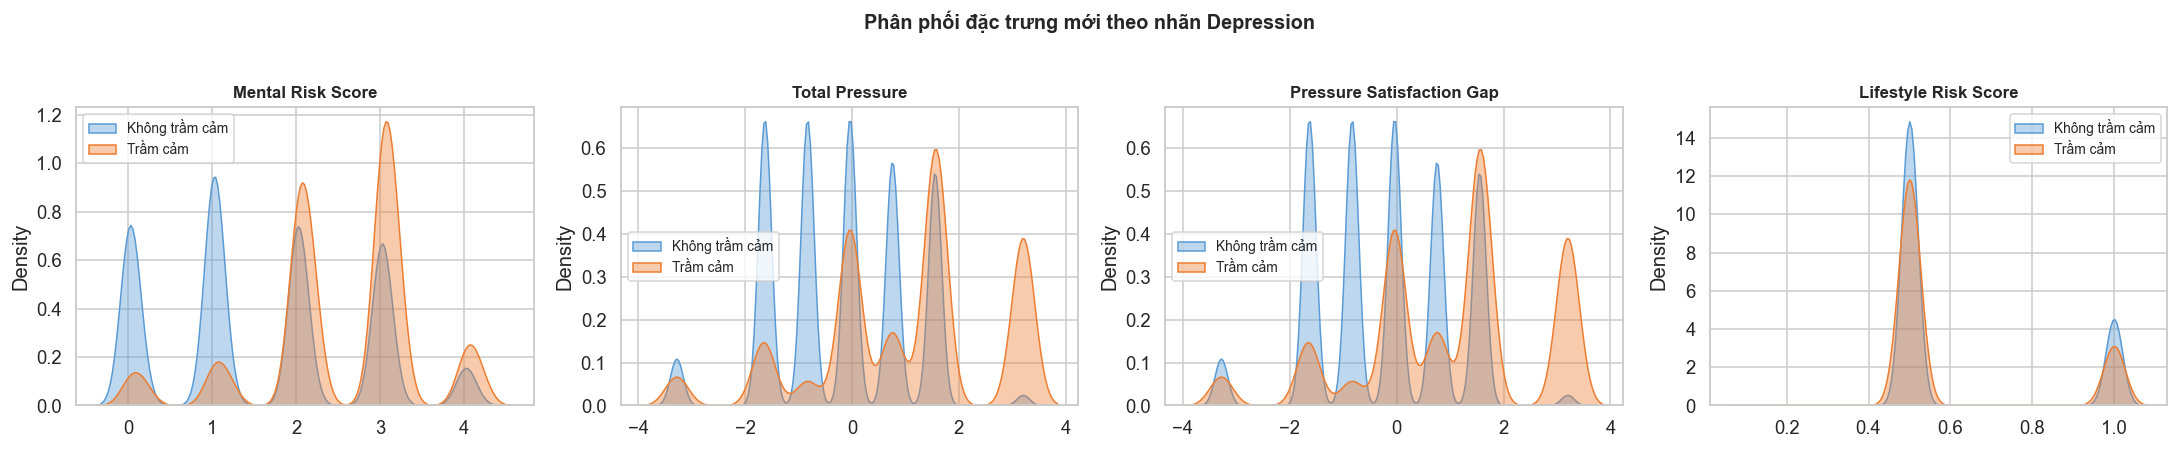

In [5]:
# In bảng thống kê các đặc trưng mới 
new_feats = [
    'Sleep_Hours_Num', 'Is_Sleep_Deprived',
    'Total_Pressure', 'Pressure_Satisfaction_Gap',
    'Work_Stress_Score', 'Academic_Stress_Score',
    'Lifestyle_Risk_Score', 'Mental_Risk_Score',
    'Age_x_Pressure', 'Hours_x_Pressure', 'Overload_Flag'
]
new_feats_exist = [f for f in new_feats if f in X_tr_fe.columns]

print('Thống kê mô tả các đặc trưng mới được tạo:')
display(
    X_tr_fe[new_feats_exist].describe().T
    .style.background_gradient(cmap='Blues', subset=['mean', 'std'])
    .format('{:.3f}')
)

# Vẽ biểu đồ phân phối theo nhãn Depression 
plot_feats = ['Mental_Risk_Score', 'Total_Pressure', 'Pressure_Satisfaction_Gap', 'Lifestyle_Risk_Score']
plot_feats = [f for f in plot_feats if f in X_tr_fe.columns]

fig, axes = plt.subplots(1, len(plot_feats), figsize=(5 * len(plot_feats), 4))
if len(plot_feats) == 1:
    axes = [axes]

for ax, feat in zip(axes, plot_feats):
    temp = pd.DataFrame({'feat': X_tr_fe[feat], 'Depression': y_tr_fe.values})
    for label, color in zip([0, 1], ['#5B9BD5', '#ED7D31']):
        sns.kdeplot(
            temp.loc[temp['Depression'] == label, 'feat'],
            ax=ax, fill=True, alpha=0.4, color=color,
            label='Không trầm cảm' if label == 0 else 'Trầm cảm'
        )
    ax.set_title(feat.replace('_', ' '), fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=9)

plt.suptitle('Phân phối đặc trưng mới theo nhãn Depression', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### Nhận xét biểu đồ phân phối các đặc trưng mới theo nhãn Depression

Biểu đồ cho thấy các đặc trưng mới tạo ra đều có khả năng hỗ trợ phân biệt giữa hai nhóm `Không bị trầm cảm` và `Trầm cảm`, dù vẫn còn hiện tượng chồng lấp giữa hai phân phối.

Trong đó, `Mental Risk Score` thể hiện sự khác biệt rõ nhất khi nhóm `Trầm cảm` tập trung nhiều hơn ở các mức điểm cao, còn nhóm `Không bị trầm cảm` thiên về các mức thấp hơn. Tương tự, `Total Pressure` và `Pressure Satisfaction Gap` cũng cho thấy nhóm `Trầm cảm` có xu hướng xuất hiện ở vùng giá trị cao hơn, cho thấy áp lực và sự mất cân bằng áp lực có liên hệ với nguy cơ trầm cảm.

Tuy nhiên, đối với `Lifestyle Risk Score`, mức độ tách biệt không mạnh bằng các biến còn lại. Nhìn chung, các đặc trưng mới này là hợp lý và có thể giúp cải thiện hiệu quả của mô hình phân loại.

### 1.4 Ma trận tương quan đặc trưng mới

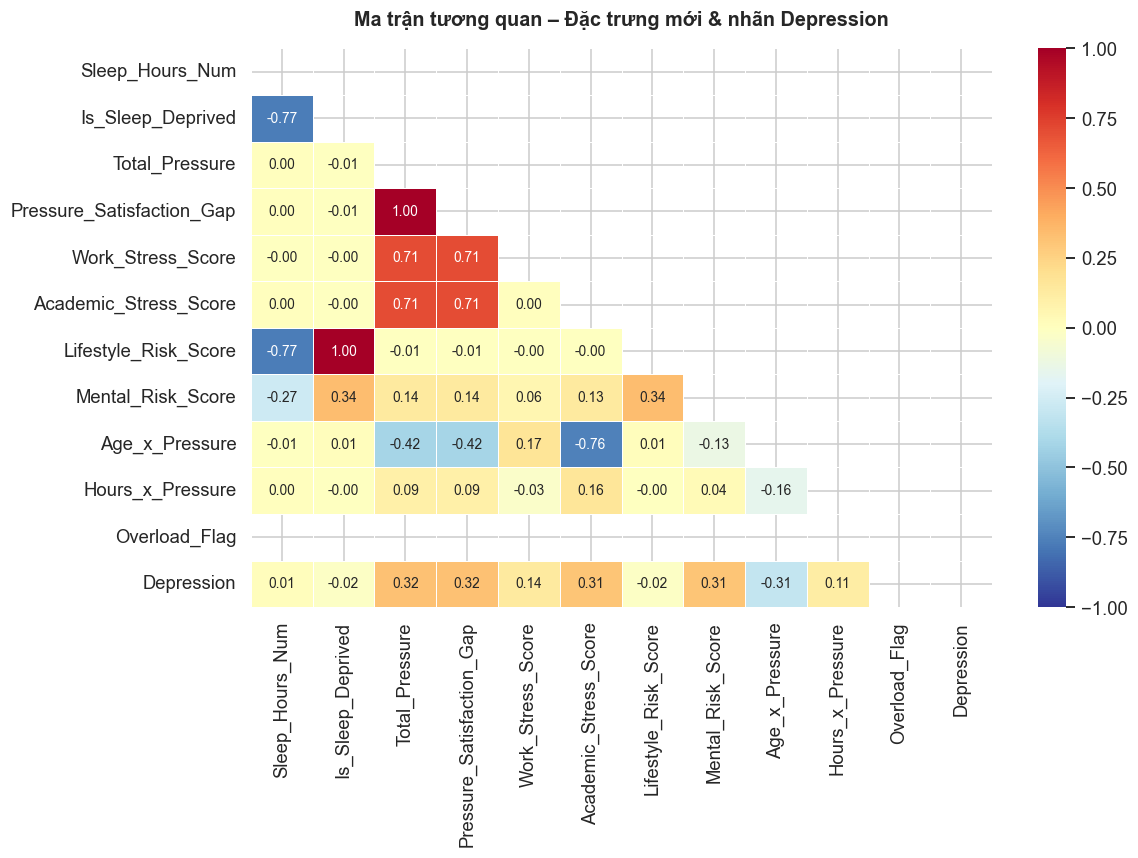


Top 8 đặc trưng mới tương quan cao nhất với Depression:


,Đặc trưng,|Tương quan|
0,Pressure_Satisfaction_Gap,0.3217
1,Total_Pressure,0.3217
2,Academic_Stress_Score,0.3079
3,Age_x_Pressure,0.3075
4,Mental_Risk_Score,0.3071
5,Work_Stress_Score,0.1378
6,Hours_x_Pressure,0.1136
7,Lifestyle_Risk_Score,0.0229


In [6]:
# Tính tương quan Pearson giữa đặc trưng mới và nhãn 
corr_df = X_tr_fe[new_feats_exist].copy()
corr_df['Depression'] = y_tr_fe.values

corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, annot_kws={'size': 9}
)
ax.set_title('Ma trận tương quan – Đặc trưng mới & nhãn Depression', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# In top đặc trưng tương quan cao nhất với Depression
target_corr = corr_matrix['Depression'].drop('Depression').abs().sort_values(ascending=False)
print('\nTop 8 đặc trưng mới tương quan cao nhất với Depression:')
display(
    target_corr.head(8).reset_index()
    .rename(columns={'index': 'Đặc trưng', 'Depression': '|Tương quan|'})
    .style.bar(subset=['|Tương quan|'], color='#5B9BD5')
    .format({'|Tương quan|': '{:.4f}'})
)

### Nhận xét ma trận tương quan giữa đặc trưng mới và nhãn Depression

Trong các đặc trưng mới, `Pressure_Satisfaction_Gap` và `Total_Pressure` có tương quan dương cao nhất với `Depression` (khoảng `0.32`), cho thấy khi áp lực tổng thể hoặc mức chênh lệch giữa áp lực và sự hài lòng tăng thì khả năng thuộc nhóm trầm cảm cũng tăng. Ngoài ra, `Academic_Stress_Score` và `Mental_Risk_Score` cũng có tương quan dương tương đối rõ (khoảng `0.31`), cho thấy áp lực học tập và rủi ro tinh thần là những tín hiệu quan trọng cho bài toán phân loại.

Đáng chú ý, `Age_x_Pressure` có tương quan âm khoảng `-0.31`, tức là đặc trưng tương tác này thay đổi theo chiều ngược lại với nhãn trầm cảm. Trong khi đó, `Work_Stress_Score` và `Hours_x_Pressure` chỉ có tương quan yếu hơn, còn `Lifestyle_Risk_Score`, `Sleep_Hours_Num` và `Is_Sleep_Deprived` gần như có liên hệ rất thấp với biến mục tiêu.

Bên cạnh đó, ma trận cũng cho thấy một số đặc trưng có tương quan rất cao với nhau, chẳng hạn `Total_Pressure` và `Pressure_Satisfaction_Gap` gần như trùng nhau (`1.00`). Điều này cho thấy có thể tồn tại hiện tượng dư thừa thông tin giữa một số biến mới tạo ra, vì vậy ở bước mô hình hóa cần cân nhắc chọn lọc đặc trưng hoặc dùng các mô hình có khả năng xử lý đa cộng tuyến tốt.

---
# **PHẦN 2 – CHUẨN BỊ DỮ LIỆU CHO CÁC MÔ HÌNH**

In [7]:
# Xử lý giá trị thiếu còn sót lại (điền bằng median) 

imputer = SimpleImputer(strategy='median')
X_tr_imp  = pd.DataFrame(imputer.fit_transform(X_tr_final),   columns=X_tr_final.columns)
X_val_imp = pd.DataFrame(imputer.transform(X_val_final),       columns=X_val_final.columns)
X_test_imp = pd.DataFrame(imputer.transform(X_test_fe),        columns=X_test_fe.columns)

# Chuẩn hóa StandardScaler (dùng cho SVM & QDA)
scaler = StandardScaler()
X_tr_scaled   = pd.DataFrame(scaler.fit_transform(X_tr_imp),   columns=X_tr_imp.columns)
X_val_scaled  = pd.DataFrame(scaler.transform(X_val_imp),       columns=X_val_imp.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imp),      columns=X_test_imp.columns)

print('    Đã chuẩn bị dữ liệu:')
print(f'   X_tr_imp   (raw)    : {X_tr_imp.shape}  | NaN: {X_tr_imp.isna().sum().sum()}')
print(f'   X_tr_scaled (scaled): {X_tr_scaled.shape}  | NaN: {X_tr_scaled.isna().sum().sum()}')

# Lưu kết quả dự đoán để so sánh sau
results_summary = []   # sẽ append dict {Model, Accuracy, AUC, F1} sau mỗi mô hình

    Đã chuẩn bị dữ liệu:
   X_tr_imp   (raw)    : (119595, 27)  | NaN: 0
   X_tr_scaled (scaled): (119595, 27)  | NaN: 0


---
# **PHẦN 3 – MÔ HÌNH 1: CatBoost Classifier**

---
### Giới thiệu CatBoost

**CatBoost** (*Categorical Boosting*) là một thuật toán thuộc họ **Gradient Boosting Decision Trees**, được phát triển bởi **Yandex**. Thuật toán này được thiết kế đặc biệt để xử lý tốt dữ liệu có nhiều biến phân loại và giảm các vấn đề thường gặp khi huấn luyện boosting trên dữ liệu thực tế.

Điểm mạnh chính:
- Xử lý biến hạng mục **native** (không cần one-hot encoding thủ công trong nhiều trường hợp)
- Sử dụng **Ordered Target Statistics** để mã hóa biến phân loại theo cách hạn chế **data leakage**
- Áp dụng cơ chế **Ordered Boosting** giúp quá trình học ổn định hơn và giảm overfitting
- Ít nhạy cảm với hyperparameter hơn so với **XGBoost** hoặc **LightGBM** trong nhiều bài toán thực tế
- Hỗ trợ huấn luyện trên **CPU** và **GPU**

Về bản chất, CatBoost xây dựng mô hình theo kiểu cộng dồn nhiều cây quyết định yếu để dần cải thiện kết quả dự đoán. Ở mỗi vòng lặp, mô hình mới sẽ học từ phần sai số còn lại của mô hình trước đó.

**Công thức cập nhật của Gradient Boosting:**
$$
F_t(x) = F_{t-1}(x) + \eta \cdot h_t(x)
$$

Trong đó:
- $F_{t-1}(x)$: mô hình ở vòng lặp trước
- $h_t(x)$: cây quyết định mới được huấn luyện để học phần sai số còn lại
- $\eta$: *learning rate*, điều chỉnh mức độ đóng góp của cây mới vào mô hình tổng
- $F_t(x)$: mô hình sau khi cập nhật ở bước $t$

Cây $h_t(x)$ được huấn luyện dựa trên **pseudo-residuals**, tức là gradient âm của hàm mất mát:
$$
r_i^{(t)} = - \frac{\partial L(y_i, F(x_i))}{\partial F(x_i)}
$$

Điều này có nghĩa là tại mỗi bước, CatBoost cố gắng bổ sung một cây mới để sửa các lỗi mà mô hình hiện tại vẫn còn mắc phải. Với bài toán phân loại nhị phân như dự đoán `Depression`, CatBoost thường tối ưu hàm mất mát như **Logloss**, từ đó cải thiện dần khả năng phân biệt giữa hai lớp.

Một điểm quan trọng của CatBoost là khả năng xử lý biến phân loại hiệu quả mà không cần mã hóa thủ công quá nhiều. Nhờ đó, mô hình thường cho kết quả tốt trên dữ liệu hỗn hợp gồm cả biến số và biến hạng mục, đồng thời giúp pipeline gọn hơn và giảm nguy cơ mất thông tin trong bước tiền xử lý.

### 3.1 Huấn luyện CatBoost với siêu tham số mặc định

In [ ]:
#  Xác định cột hạng mục còn lại (nếu có) 
cat_features_cb = []  # Sau FE và target-encoding, hầu hết đã là số

#  Khởi tạo và huấn luyện CatBoost 
print('Đang huấn luyện CatBoost (baseline)...')

catboost_base = CatBoostClassifier(
    iterations      = 1000,
    learning_rate   = 0.05,
    depth           = 6,
    loss_function   = 'Logloss',
    eval_metric     = 'AUC',
    random_seed     = 42,
    verbose         = 0,          # tắt log
    allow_writing_files=False,
    early_stopping_rounds = 50,
)

catboost_base.fit(
    X_tr_imp, y_tr_final,
    eval_set    = (X_val_imp, y_val_final),
    use_best_model = True,
)

# Đánh giá 
y_pred_cb_base  = catboost_base.predict(X_val_imp)
y_prob_cb_base  = catboost_base.predict_proba(X_val_imp)[:, 1]

acc_cb  = accuracy_score(y_val_final, y_pred_cb_base)
auc_cb  = roc_auc_score(y_val_final, y_prob_cb_base)
f1_cb   = f1_score(y_val_final, y_pred_cb_base)

print(f'\n KẾT QUẢ CATBOOST BASELINE:')
print(f'   Accuracy  : {acc_cb:.4f}')
print(f'   ROC-AUC   : {auc_cb:.4f}')
print(f'   F1-Score  : {f1_cb:.4f}')
print(f'   Best iter : {catboost_base.get_best_iteration()}')

Đang huấn luyện CatBoost (baseline)...

 KẾT QUẢ CATBOOST BASELINE:
   Accuracy  : 0.9395
   ROC-AUC   : 0.9747
   F1-Score  : 0.8301
   Best iter : 454


### 3.2 Tối ưu CatBoost bằng RandomizedSearchCV

Để cải thiện hiệu quả của mô hình CatBoost, nhóm sử dụng `RandomizedSearchCV` nhằm tìm kiếm một số tổ hợp siêu tham số quan trọng trong không gian tham số đã xác định trước. So với việc thử thủ công, cách tiếp cận này giúp tìm được cấu hình phù hợp nhanh hơn và có hệ thống hơn.

Các siêu tham số được lựa chọn gồm:
- `depth`: kiểm soát độ sâu của cây, ảnh hưởng đến khả năng học quan hệ phức tạp
- `learning_rate`: điều chỉnh tốc độ cập nhật của mô hình qua mỗi vòng boosting
- `l2_leaf_reg`: hệ số regularization giúp giảm overfitting
- `subsample`: tỷ lệ mẫu được sử dụng ở mỗi cây để tăng tính tổng quát
- `min_data_in_leaf`: số mẫu tối thiểu trong mỗi lá, giúp hạn chế cây tách quá chi tiết

Trong quá trình tìm kiếm, mô hình được đánh giá bằng `StratifiedKFold` để giữ cân bằng tỷ lệ lớp giữa các fold, đồng thời sử dụng chỉ số `ROC-AUC` làm tiêu chí lựa chọn mô hình tốt nhất. Kết quả cuối cùng trả về bộ siêu tham số tối ưu và giá trị `CV AUC` tương ứng.

In [ ]:
param_dist_cb = {
    'depth'        : [4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'l2_leaf_reg'  : [1, 3, 5, 7, 10],
    'subsample'    : [0.7, 0.8, 0.9, 1.0],
    'min_data_in_leaf': [5, 10, 20],
}

catboost_search = CatBoostClassifier(
    iterations   = 500,
    loss_function= 'Logloss',
    eval_metric  = 'AUC',
    random_seed  = 42,
    verbose      = 0,
    allow_writing_files=False,
)

print('Đang tìm kiếm siêu tham số CatBoost (n_iter=20)...')
cb_random = RandomizedSearchCV(
    catboost_search, param_dist_cb,
    n_iter=20, scoring='roc_auc',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    n_jobs=-1, verbose=0, random_state=42
)
cb_random.fit(X_tr_imp, y_tr_final)

print(f'\n Tham số tốt nhất: {cb_random.best_params_}')
print(f'   CV AUC tốt nhất  : {cb_random.best_score_:.4f}')

Đang tìm kiếm siêu tham số CatBoost (n_iter=20)...

 Tham số tốt nhất: {'subsample': 1.0, 'min_data_in_leaf': 20, 'learning_rate': 0.05, 'l2_leaf_reg': 3, 'depth': 5}
   CV AUC tốt nhất  : 0.9752


In [ ]:
# Huấn luyện lại với tham số tốt nhất 
best_cb = CatBoostClassifier(
    iterations   = 1000,
    loss_function= 'Logloss',
    eval_metric  = 'AUC',
    random_seed  = 42,
    verbose      = 0,
    allow_writing_files=False,
    early_stopping_rounds = 50,
    **cb_random.best_params_
)
best_cb.fit(
    X_tr_imp, y_tr_final,
    eval_set=(X_val_imp, y_val_final),
    use_best_model=True
)

y_pred_cb  = best_cb.predict(X_val_imp)
y_prob_cb  = best_cb.predict_proba(X_val_imp)[:, 1]

acc_cb_opt = accuracy_score(y_val_final, y_pred_cb)
auc_cb_opt = roc_auc_score(y_val_final, y_prob_cb)
f1_cb_opt  = f1_score(y_val_final, y_pred_cb)

print('\n  KẾT QUẢ CATBOOST ĐÃ TỐI ƯU:')
print(f'   Accuracy  : {acc_cb_opt:.4f}   (baseline: {acc_cb:.4f})')
print(f'   ROC-AUC   : {auc_cb_opt:.4f}   (baseline: {auc_cb:.4f})')
print(f'   F1-Score  : {f1_cb_opt:.4f}   (baseline: {f1_cb:.4f})')

# Lưu kết quả
results_summary.append({'Mô hình': 'CatBoost', 'Accuracy': acc_cb_opt, 'ROC-AUC': auc_cb_opt, 'F1-Score': f1_cb_opt})


  KẾT QUẢ CATBOOST ĐÃ TỐI ƯU:
   Accuracy  : 0.9399   (baseline: 0.9395)
   ROC-AUC   : 0.9748   (baseline: 0.9747)
   F1-Score  : 0.8311   (baseline: 0.8301)


### 3.3 Phân tích CatBoost: Feature Importance & Confusion Matrix

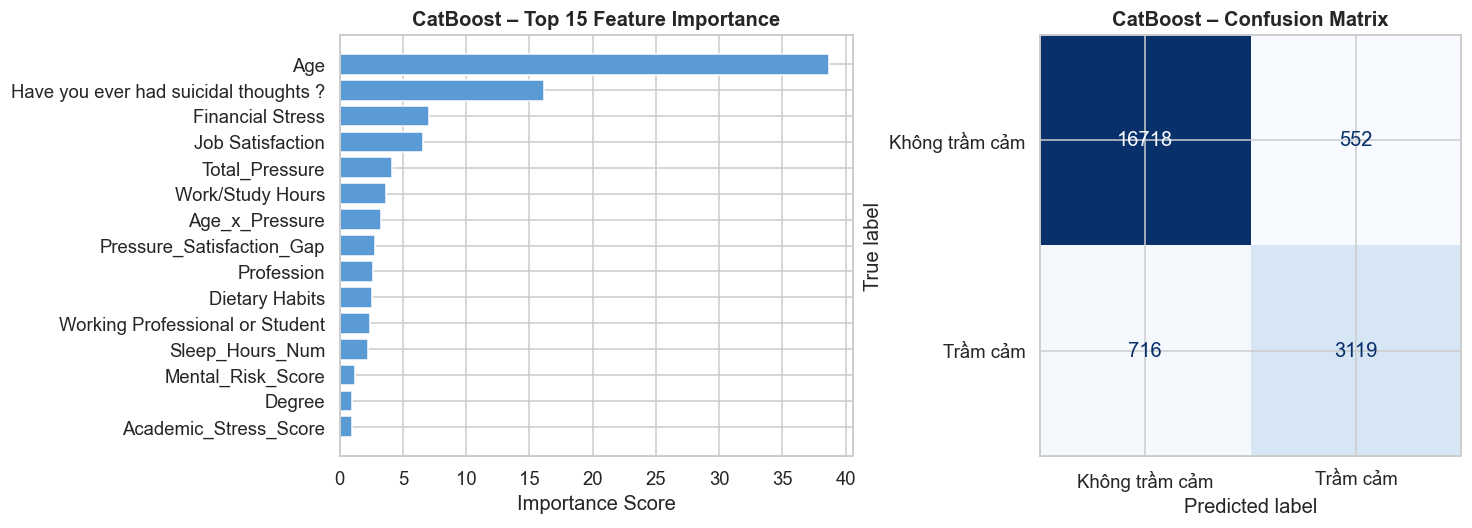


 Classification Report – CatBoost:
                precision    recall  f1-score   support

Không trầm cảm       0.96      0.97      0.96     17270
      Trầm cảm       0.85      0.81      0.83      3835

      accuracy                           0.94     21105
     macro avg       0.90      0.89      0.90     21105
  weighted avg       0.94      0.94      0.94     21105



In [11]:
# Feature Importance 
fi_cb = pd.DataFrame({
    'Feature'   : X_tr_imp.columns,
    'Importance': best_cb.get_feature_importance()
}).sort_values('Importance', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ độ quan trọng
axes[0].barh(fi_cb['Feature'][::-1], fi_cb['Importance'][::-1], color='#5B9BD5')
axes[0].set_xlabel('Importance Score')
axes[0].set_title('CatBoost – Top 15 Feature Importance', fontweight='bold')

# Confusion Matrix
cm_cb = confusion_matrix(y_val_final, y_pred_cb)
disp = ConfusionMatrixDisplay(cm_cb, display_labels=['Không trầm cảm', 'Trầm cảm'])
disp.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('CatBoost – Confusion Matrix', fontweight='bold')

plt.tight_layout()
plt.show()

# Classification Report
print('\n Classification Report – CatBoost:')
print(classification_report(y_val_final, y_pred_cb, target_names=['Không trầm cảm', 'Trầm cảm']))

### Nhận xét kết quả mô hình CatBoost

Kết quả cho thấy mô hình CatBoost hoạt động khá tốt trên bài toán phân loại `Depression`, với `Accuracy = 0.9399`, `ROC-AUC = 0.9748` và `F1-score = 0.8311`. Các chỉ số này cho thấy mô hình không chỉ phân loại đúng ở mức cao mà còn có khả năng phân biệt hai lớp rất tốt.

Từ `Classification Report`, mô hình dự đoán lớp `Không trầm cảm` tốt hơn lớp `Trầm cảm`. Cụ thể, lớp `Không trầm cảm` đạt `Precision = 0.96`, `Recall = 0.97`, `F1-score = 0.96`, trong khi lớp `Trầm cảm` đạt `Precision = 0.85`, `Recall = 0.81`, `F1-score = 0.83`. Điều này cho thấy mô hình vẫn nhận diện được lớp trầm cảm khá tốt, nhưng còn bỏ sót một số trường hợp dương tính.

`Confusion Matrix` cũng phản ánh điều đó: mô hình dự đoán đúng `16,718` mẫu không trầm cảm và `3,119` mẫu trầm cảm. Tuy nhiên, vẫn còn `716` trường hợp trầm cảm bị dự đoán nhầm thành không trầm cảm và `552` trường hợp không trầm cảm bị dự đoán nhầm thành trầm cảm. Nhìn chung, số lỗi không quá lớn so với tổng thể, nhưng với bài toán sức khỏe tinh thần thì các trường hợp bỏ sót lớp trầm cảm vẫn cần được chú ý.

Về mức độ quan trọng của đặc trưng, `Age` là biến có ảnh hưởng lớn nhất đến quyết định của mô hình. Sau đó là các đặc trưng như `Have you ever had suicidal thoughts?`, `Financial Stress`, `Job Satisfaction`, `Total_Pressure`, `Pressure_Satisfaction_Gap` và `Age_x_Pressure`. Điều này cho thấy mô hình không chỉ dựa vào đặc trưng gốc mà còn khai thác khá tốt các đặc trưng mới đã được tạo ra trong bước feature engineering.

So với mô hình CatBoost baseline, phiên bản tối ưu siêu tham số chỉ cải thiện nhẹ (`Accuracy`, `ROC-AUC`, `F1-score` đều tăng rất ít). Điều này cho thấy cấu hình ban đầu đã khá tốt và quá trình tuning chủ yếu giúp mô hình ổn định hơn thay vì tạo ra bước nhảy lớn về hiệu năng.

---
# **PHẦN 4 – MÔ HÌNH 2: QDA (Quadratic Discriminant Analysis)**

---
### Giới thiệu QDA

**QDA** (*Quadratic Discriminant Analysis*) là phương pháp phân loại dựa trên lý thuyết xác suất và phân phối thống kê. Mô hình giả định rằng dữ liệu của mỗi lớp được sinh ra từ **phân phối Gaussian đa biến**, nhưng khác với LDA, mỗi lớp trong QDA được phép có **ma trận hiệp phương sai riêng**. Nhờ đó, QDA có khả năng mô hình hóa ranh giới phân lớp linh hoạt hơn, đặc biệt khi độ phân tán của các lớp là khác nhau.

**Hàm phán quyết của QDA:**
$$
\delta_k(x) = -\frac{1}{2}\log|\Sigma_k| - \frac{1}{2}(x-\mu_k)^T\Sigma_k^{-1}(x-\mu_k) + \log\pi_k
$$

Trong đó:
- $\mu_k$ là vector trung bình của lớp $k$
- $\Sigma_k$ là ma trận hiệp phương sai của lớp $k$
- $\pi_k$ là xác suất tiên nghiệm của lớp $k$
- $x$ là mẫu đầu vào cần phân loại

Mô hình sẽ tính giá trị $\delta_k(x)$ cho từng lớp và gán mẫu vào lớp có giá trị lớn nhất. Do mỗi lớp có ma trận hiệp phương sai riêng nên ranh giới quyết định tạo ra thường có dạng **phi tuyến**, cụ thể là **bậc hai**, đây cũng là lý do phương pháp này được gọi là *Quadratic* Discriminant Analysis.

**Ưu điểm:** Nhanh, ít cần tinh chỉnh siêu tham số, có thể hoạt động tốt khi dữ liệu gần với giả định Gaussian và mối quan hệ phân lớp không tuyến tính.  

**Nhược điểm:** Nhạy với outlier, dễ giảm hiệu quả khi số đặc trưng lớn hoặc dữ liệu không tuân theo giả định phân phối, và thường cần số mẫu đủ lớn trong mỗi lớp để ước lượng ổn định ma trận hiệp phương sai.

### 4.1 Huấn luyện & đánh giá QDA

#### Chuẩn bị dữ liệu và lựa chọn `reg_param` cho QDA

Do QDA giả định mỗi lớp có ma trận hiệp phương sai riêng, mô hình thường hoạt động tốt hơn khi dữ liệu đã được **chuẩn hóa** và có số chiều phù hợp. Nếu số đặc trưng quá lớn hoặc giữa các đặc trưng tồn tại tương quan mạnh, ma trận hiệp phương sai có thể trở nên gần suy biến, làm mô hình kém ổn định.

Vì vậy, trước khi huấn luyện QDA, nhóm áp dụng **PCA** để giảm số chiều nhưng vẫn giữ lại phần lớn thông tin của dữ liệu. Trong thí nghiệm này, PCA được cấu hình để giữ **95% phương sai**, nhằm cân bằng giữa việc giảm nhiễu và bảo toàn đặc trưng quan trọng.

Sau đó, nhóm tiến hành thử nhiều giá trị `reg_param` cho QDA. Tham số này đóng vai trò **regularization** cho ma trận hiệp phương sai, giúp mô hình ổn định hơn và hạn chế hiện tượng overfitting hoặc lỗi do ma trận không khả nghịch. Việc lựa chọn giá trị tốt nhất được thực hiện bằng **cross-validation** với chỉ số đánh giá là **ROC-AUC**, từ đó tìm ra cấu hình phù hợp nhất cho mô hình QDA.

In [12]:
# QDA hoạt động tốt nhất khi dữ liệu đã được chuẩn hóa và giảm chiều
# Ta dùng PCA để giảm chiều, tránh vấn đề ma trận hiệp phương sai suy biến

# Bước 1: PCA → giữ 95% phương sai 
pca = PCA(n_components=0.95, random_state=42)
X_tr_pca   = pca.fit_transform(X_tr_scaled)
X_val_pca  = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f'PCA: {X_tr_scaled.shape[1]} → {X_tr_pca.shape[1]} chiều (giữ 95% phương sai)')

# Bước 2: Thử các giá trị reg_param (regularization) 
# reg_param ∈ [0,1]: regularize ma trận hiệp phương sai về dạng diagonal
print('\nTìm kiếm reg_param tối ưu cho QDA...')
qda_cv_results = []
for reg in [0.0, 0.001, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5]:
    qda_tmp = QuadraticDiscriminantAnalysis(reg_param=reg)
    cv_auc = cross_val_score(
        qda_tmp, X_tr_pca, y_tr_final,
        cv=StratifiedKFold(5, shuffle=True, random_state=42),
        scoring='roc_auc', n_jobs=-1
    ).mean()
    qda_cv_results.append({'reg_param': reg, 'CV AUC': cv_auc})

qda_cv_df = pd.DataFrame(qda_cv_results)
best_reg   = qda_cv_df.loc[qda_cv_df['CV AUC'].idxmax(), 'reg_param']

print('\nKết quả CV theo reg_param:')
display(qda_cv_df)
print(f'\nreg_param tốt nhất: {best_reg}')

PCA: 27 → 17 chiều (giữ 95% phương sai)

Tìm kiếm reg_param tối ưu cho QDA...

Kết quả CV theo reg_param:


,reg_param,CV AUC
0,0.0000,0.9362
1,0.0010,0.9362
2,0.0100,0.9364
3,0.0500,0.9369
4,0.1000,0.9376
5,0.2000,0.9386
6,0.3000,0.9395
7,0.5000,0.9413



reg_param tốt nhất: 0.5



  KẾT QUẢ QDA:
   Accuracy  : 0.8840
   ROC-AUC   : 0.9395
   F1-Score  : 0.7098


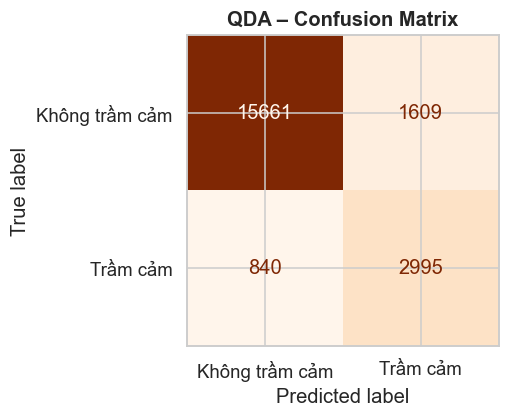


Classification Report – QDA:
                precision    recall  f1-score   support

Không trầm cảm       0.95      0.91      0.93     17270
      Trầm cảm       0.65      0.78      0.71      3835

      accuracy                           0.88     21105
     macro avg       0.80      0.84      0.82     21105
  weighted avg       0.89      0.88      0.89     21105



In [13]:
# Bước 3: Huấn luyện QDA tốt nhất 
best_qda = QuadraticDiscriminantAnalysis(reg_param=best_reg)
best_qda.fit(X_tr_pca, y_tr_final)

y_pred_qda = best_qda.predict(X_val_pca)
y_prob_qda = best_qda.predict_proba(X_val_pca)[:, 1]

acc_qda = accuracy_score(y_val_final, y_pred_qda)
auc_qda = roc_auc_score(y_val_final, y_prob_qda)
f1_qda  = f1_score(y_val_final, y_pred_qda)

print('\n  KẾT QUẢ QDA:')
print(f'   Accuracy  : {acc_qda:.4f}')
print(f'   ROC-AUC   : {auc_qda:.4f}')
print(f'   F1-Score  : {f1_qda:.4f}')

results_summary.append({'Mô hình': 'QDA', 'Accuracy': acc_qda, 'ROC-AUC': auc_qda, 'F1-Score': f1_qda})

# Confusion matrix & Report 
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
cm_qda = confusion_matrix(y_val_final, y_pred_qda)
ConfusionMatrixDisplay(cm_qda, display_labels=['Không trầm cảm', 'Trầm cảm']).plot(ax=ax, cmap='Oranges', colorbar=False)
ax.set_title('QDA – Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nClassification Report – QDA:')
print(classification_report(y_val_final, y_pred_qda, target_names=['Không trầm cảm', 'Trầm cảm']))

### Nhận xét kết quả mô hình QDA

Kết quả cho thấy mô hình QDA đạt `Accuracy = 0.88`, cho thấy khả năng phân loại ở mức khá. Tuy nhiên, hiệu quả giữa hai lớp chưa thật sự cân bằng, đặc biệt ở lớp `Trầm cảm`.

Từ `Classification Report`, lớp `Không trầm cảm` được dự đoán tốt hơn rõ rệt với `Precision = 0.95`, `Recall = 0.91` và `F1-score = 0.93`. Trong khi đó, lớp `Trầm cảm` chỉ đạt `Precision = 0.65`, `Recall = 0.78` và `F1-score = 0.71`. Điều này cho thấy mô hình nhận diện được khá nhiều trường hợp trầm cảm, nhưng độ chính xác ở lớp này còn thấp, tức là vẫn có khá nhiều dự đoán dương tính chưa thật sự đúng.

`Confusion Matrix` cho thấy mô hình dự đoán đúng `15,661` mẫu không trầm cảm và `2,995` mẫu trầm cảm. Tuy nhiên, vẫn có `1,609` mẫu không trầm cảm bị nhầm thành trầm cảm và `840` mẫu trầm cảm bị bỏ sót, dự đoán thành không trầm cảm. Như vậy, QDA có xu hướng bắt được lớp trầm cảm tốt hơn về `recall`, nhưng phải đánh đổi bằng số lượng dự đoán nhầm cao hơn.

Nhìn chung, QDA là một mô hình khá nhanh và đơn giản, cho kết quả tương đối ổn trên bài toán này. Tuy nhiên, so với các mô hình mạnh hơn, hiệu quả tổng thể và đặc biệt là `F1-score` của lớp `Trầm cảm` vẫn còn hạn chế, nên QDA phù hợp hơn với vai trò mô hình đối chứng hoặc baseline hơn là mô hình tối ưu cuối cùng.

---
# **PHẦN 5 – MÔ HÌNH 4: LightGBM (DART / GOSS / GBDT)**

---
### Giới thiệu LightGBM và các biến thể

**LightGBM** (*Light Gradient Boosting Machine*) là framework Gradient Boosting do **Microsoft** phát triển, được thiết kế để huấn luyện nhanh, tiết kiệm bộ nhớ và hoạt động hiệu quả trên dữ liệu lớn. LightGBM xây dựng mô hình theo hướng cộng dồn nhiều cây quyết định, trong đó mỗi cây mới được huấn luyện để sửa sai số của các cây trước đó.

So với nhiều thư viện boosting khác, LightGBM nổi bật ở khả năng:
- huấn luyện nhanh trên tập dữ liệu lớn
- tối ưu bộ nhớ tốt
- hỗ trợ số lượng đặc trưng lớn
- cho hiệu quả cao trên các bài toán phân loại và hồi quy dạng bảng

Ba boosting algorithm chính:

| Biến thể | Mô tả | Ưu điểm |
|---|---|---|
| **GBDT** | Traditional Gradient Boosting | Ổn định, dễ dùng, là baseline mạnh |
| **DART** | Dropouts meet Multiple Additive Regression Trees | Giảm overfitting bằng cơ chế dropout trên cây |
| **GOSS** | Gradient-based One-Side Sampling | Tăng tốc huấn luyện bằng cách ưu tiên các mẫu có gradient lớn |

#### 1. GBDT
**GBDT** là phiên bản boosting tiêu chuẩn, trong đó các cây được thêm lần lượt để tối ưu dần hàm mất mát. Đây là biến thể phổ biến nhất, thường được dùng làm mốc so sánh ban đầu vì tính ổn định và hiệu quả tốt trên nhiều bài toán.

#### 2. DART
**DART** mở rộng từ GBDT bằng cách áp dụng ý tưởng tương tự **dropout** trong neural network. Ở mỗi vòng lặp, một số cây trước đó được tạm thời bỏ qua khi huấn luyện cây mới. Cách này giúp mô hình không phụ thuộc quá nhiều vào một vài cây mạnh, từ đó giảm nguy cơ overfitting và tăng khả năng tổng quát hóa.

#### 3. GOSS
**GOSS** (*Gradient-based One-Side Sampling*) là biến thể giúp LightGBM huấn luyện nhanh hơn. Ý tưởng chính là không cần dùng toàn bộ dữ liệu ở mỗi lần tách cây, mà sẽ:
- giữ lại toàn bộ các mẫu có **gradient lớn** vì đây là các mẫu khó học hoặc đang bị dự đoán sai nhiều
- chỉ lấy ngẫu nhiên một phần các mẫu có **gradient nhỏ** vì chúng mang ít thông tin hơn
- gán trọng số bù cho nhóm gradient nhỏ được lấy mẫu để giảm sai lệch thống kê

Nhờ vậy, GOSS vẫn giữ được phần dữ liệu quan trọng nhất cho việc học, trong khi giảm đáng kể chi phí tính toán.

**GOSS – Công thức ước lượng gain:**
$$
\tilde{V}_j(d) = \frac{1}{n}\left(\sum_{x_i \in A_l} g_i^2 + \frac{1-a}{b}\sum_{x_i \in B_l} g_i^2\right)
$$

Trong đó:
- $A_l$ là tập các mẫu có **gradient lớn** được giữ lại toàn bộ
- $B_l$ là tập các mẫu có **gradient nhỏ** được lấy mẫu ngẫu nhiên
- $g_i$ là gradient của mẫu thứ $i$
- $a$ là tỷ lệ mẫu gradient lớn được giữ lại
- $b$ là tỷ lệ lấy mẫu trong nhóm gradient nhỏ
- $\frac{1-a}{b}$ là hệ số hiệu chỉnh trọng số để bù cho phần dữ liệu gradient nhỏ đã bị lược bớt

Nói ngắn gọn, công thức trên giúp LightGBM ước lượng độ lợi khi chia node mà không cần dùng toàn bộ dữ liệu, nhưng vẫn cố gắng giữ cho kết quả gần với trường hợp tính trên tập đầy đủ.

Nhìn chung:
- **GBDT** phù hợp khi cần một mô hình mạnh và ổn định
- **DART** phù hợp khi muốn giảm overfitting
- **GOSS** phù hợp khi cần tăng tốc huấn luyện mà vẫn giữ hiệu quả dự đoán tốt

Vì vậy, việc thử nhiều biến thể của LightGBM trong bài toán phân loại là hợp lý để so sánh giữa độ chính xác, tốc độ huấn luyện và khả năng tổng quát hóa của mô hình.

### 5.1 LightGBM – GBDT (baseline)

#### Huấn luyện mô hình LightGBM với biến thể GBDT

Để đánh giá hiệu quả của LightGBM trên bài toán phân loại `Depression`, nhóm trước hết thử nghiệm biến thể **GBDT** (*Gradient Boosting Decision Tree*), đây là phiên bản boosting tiêu chuẩn và cũng là lựa chọn nền tảng phổ biến nhất của LightGBM.

Trong thí nghiệm này, một bộ siêu tham số chung được thiết lập nhằm kiểm soát độ phức tạp của mô hình, tốc độ học và khả năng khái quát hóa. Cụ thể:
- `n_estimators = 1000`: số lượng cây tối đa được phép huấn luyện
- `learning_rate = 0.05`: tốc độ học, quyết định mức đóng góp của mỗi cây mới vào mô hình
- `num_leaves = 63`: số lá tối đa trong mỗi cây, ảnh hưởng trực tiếp đến khả năng học quan hệ phức tạp
- `max_depth = -1`: không giới hạn độ sâu cây, cho phép cây phát triển linh hoạt
- `min_child_samples = 20`: số mẫu tối thiểu trong một lá, giúp hạn chế việc tách quá nhỏ gây overfitting
- `subsample = 0.8`: mỗi cây chỉ dùng ngẫu nhiên 80% số mẫu huấn luyện
- `colsample_bytree = 0.8`: mỗi cây chỉ dùng ngẫu nhiên 80% số đặc trưng
- `reg_alpha = 0.1` và `reg_lambda = 0.1`: hệ số regularization L1 và L2, giúp mô hình ổn định hơn và giảm nguy cơ overfitting

Ngoài ra, quá trình huấn luyện sử dụng **early stopping** trên tập validation. Cơ chế này cho phép mô hình tự dừng khi chỉ số đánh giá không còn cải thiện sau 50 vòng lặp liên tiếp, từ đó giảm thời gian huấn luyện và tránh học quá mức trên dữ liệu train.

Sau khi huấn luyện, mô hình được đánh giá trên tập validation thông qua ba chỉ số chính gồm `Accuracy`, `ROC-AUC` và `F1-score`, nhằm xem xét cả độ chính xác tổng thể lẫn khả năng phân biệt hai lớp trong bài toán phân loại nhị phân.

In [14]:
# Tham số chung 
lgb_common = dict(
    objective       = 'binary',
    metric          = 'auc',
    n_estimators    = 1000,
    learning_rate   = 0.05,
    num_leaves      = 63,
    max_depth       = -1,
    min_child_samples = 20,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    reg_alpha       = 0.1,
    reg_lambda      = 0.1,
    random_state    = 42,
    verbose         = -1,
    n_jobs          = -1,
)

callbacks = [lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]

# GBDT
print('Huấn luyện LightGBM – GBDT...')
lgb_gbdt = lgb.LGBMClassifier(boosting_type='gbdt', **lgb_common)
lgb_gbdt.fit(
    X_tr_imp, y_tr_final,
    eval_set=[(X_val_imp, y_val_final)],
    callbacks=callbacks
)

y_pred_gbdt = lgb_gbdt.predict(X_val_imp)
y_prob_gbdt = lgb_gbdt.predict_proba(X_val_imp)[:, 1]

acc_gbdt = accuracy_score(y_val_final, y_pred_gbdt)
auc_gbdt = roc_auc_score(y_val_final, y_prob_gbdt)
f1_gbdt  = f1_score(y_val_final, y_pred_gbdt)

print(f'LightGBM GBDT → Accuracy: {acc_gbdt:.4f} | AUC: {auc_gbdt:.4f} | F1: {f1_gbdt:.4f}')
results_summary.append({'Mô hình': 'LightGBM GBDT', 'Accuracy': acc_gbdt, 'ROC-AUC': auc_gbdt, 'F1-Score': f1_gbdt})

Huấn luyện LightGBM – GBDT...
LightGBM GBDT → Accuracy: 0.9386 | AUC: 0.9742 | F1: 0.8286


### 5.2 LightGBM – DART (với dropout)

#### Huấn luyện mô hình LightGBM với biến thể DART

Sau khi thử nghiệm biến thể GBDT, nhóm tiếp tục đánh giá **LightGBM DART** (*Dropouts meet Multiple Additive Regression Trees*). Đây là biến thể mở rộng của boosting truyền thống, trong đó một số cây đã học trước đó sẽ được tạm thời “drop” ở mỗi vòng lặp, tương tự ý tưởng dropout trong mạng nơ-ron. Cơ chế này giúp giảm sự phụ thuộc quá mức vào một số cây mạnh và góp phần hạn chế overfitting.

Một số tham số đặc trưng của DART được sử dụng trong thí nghiệm gồm:
- `drop_rate`: tỷ lệ cây bị dropout trong mỗi vòng boosting
- `skip_drop`: xác suất bỏ qua bước dropout
- `max_drop`: số lượng cây tối đa có thể bị dropout

Do DART không hỗ trợ early stopping hiệu quả như GBDT, mô hình được huấn luyện với số lượng `n_estimators` cố định. Sau khi huấn luyện, mô hình được đánh giá trên tập validation thông qua ba chỉ số chính là `Accuracy`, `ROC-AUC` và `F1-score` để so sánh với các biến thể khác của LightGBM.

In [15]:
# DART thêm dropout vào boosting để giảm overfitting
# Tham số đặc trưng của DART:
#   drop_rate   : tỷ lệ cây bị dropout mỗi vòng
#   skip_drop   : xác suất bỏ qua dropout
#   max_drop    : số cây tối đa bị dropout

print('Huấn luyện LightGBM – DART...')
lgb_dart = lgb.LGBMClassifier(
    boosting_type = 'dart',
    drop_rate     = 0.1,
    skip_drop     = 0.5,
    max_drop      = 50,
    **lgb_common
)
# Lưu ý: DART không hỗ trợ early stopping hoàn toàn → dùng n_estimators cố định
lgb_dart.fit(
    X_tr_imp, y_tr_final,
    eval_set=[(X_val_imp, y_val_final)],
    callbacks=[lgb.log_evaluation(-1)]
)

y_pred_dart = lgb_dart.predict(X_val_imp)
y_prob_dart = lgb_dart.predict_proba(X_val_imp)[:, 1]

acc_dart = accuracy_score(y_val_final, y_pred_dart)
auc_dart = roc_auc_score(y_val_final, y_prob_dart)
f1_dart  = f1_score(y_val_final, y_pred_dart)

print(f'LightGBM DART → Accuracy: {acc_dart:.4f} | AUC: {auc_dart:.4f} | F1: {f1_dart:.4f}')
results_summary.append({'Mô hình': 'LightGBM DART', 'Accuracy': acc_dart, 'ROC-AUC': auc_dart, 'F1-Score': f1_dart})

Huấn luyện LightGBM – DART...
LightGBM DART → Accuracy: 0.9393 | AUC: 0.9741 | F1: 0.8289


### 5.3 LightGBM – GOSS (Gradient-based One-Side Sampling)

#### Huấn luyện mô hình LightGBM với biến thể GOSS

Tiếp theo, nhóm thử nghiệm **LightGBM GOSS** (*Gradient-based One-Side Sampling*), một biến thể được thiết kế để tăng tốc quá trình huấn luyện bằng cách ưu tiên các mẫu quan trọng hơn trong mỗi vòng boosting. Thay vì sử dụng toàn bộ dữ liệu, GOSS sẽ giữ lại tất cả các mẫu có **gradient lớn** vì đây là những mẫu mà mô hình hiện tại dự đoán chưa tốt, đồng thời chỉ lấy ngẫu nhiên một phần các mẫu có **gradient nhỏ** để giảm chi phí tính toán.

Trong thí nghiệm này, mô hình vẫn sử dụng bộ siêu tham số chung của LightGBM để đảm bảo tính nhất quán khi so sánh với các biến thể khác. Bên cạnh đó, GOSS có thêm hai tham số đặc trưng:
- `top_rate = 0.2`: giữ lại 20% mẫu có gradient lớn nhất
- `other_rate = 0.1`: lấy ngẫu nhiên 10% mẫu từ nhóm có gradient nhỏ

Cách lấy mẫu này giúp mô hình tập trung nhiều hơn vào các quan sát khó, từ đó vừa rút ngắn thời gian huấn luyện vừa vẫn giữ được hiệu quả dự đoán. Tương tự biến thể GBDT, quá trình huấn luyện cũng sử dụng **early stopping** trên tập validation để tự dừng khi kết quả không còn cải thiện.

Sau khi huấn luyện, mô hình được đánh giá trên tập validation thông qua ba chỉ số chính là `Accuracy`, `ROC-AUC` và `F1-score`, nhằm so sánh hiệu quả giữa GOSS với các biến thể còn lại của LightGBM.

In [16]:
# GOSS giữ tất cả mẫu có gradient lớn và lấy mẫu ngẫu nhiên mẫu gradient nhỏ
# Tham số đặc trưng:
#   top_rate     : tỷ lệ mẫu gradient lớn được giữ (mặc định 0.2)
#   other_rate   : tỷ lệ mẫu gradient nhỏ được lấy ngẫu nhiên (mặc định 0.1)

print('Huấn luyện LightGBM – GOSS...')
lgb_goss = lgb.LGBMClassifier(
    boosting_type = 'goss',
    top_rate      = 0.2,
    other_rate    = 0.1,
    **lgb_common
)
lgb_goss.fit(
    X_tr_imp, y_tr_final,
    eval_set=[(X_val_imp, y_val_final)],
    callbacks=callbacks
)

y_pred_goss = lgb_goss.predict(X_val_imp)
y_prob_goss = lgb_goss.predict_proba(X_val_imp)[:, 1]

acc_goss = accuracy_score(y_val_final, y_pred_goss)
auc_goss = roc_auc_score(y_val_final, y_prob_goss)
f1_goss  = f1_score(y_val_final, y_pred_goss)

print(f'LightGBM GOSS → Accuracy: {acc_goss:.4f} | AUC: {auc_goss:.4f} | F1: {f1_goss:.4f}')
results_summary.append({'Mô hình': 'LightGBM GOSS', 'Accuracy': acc_goss, 'ROC-AUC': auc_goss, 'F1-Score': f1_goss})

Huấn luyện LightGBM – GOSS...
LightGBM GOSS → Accuracy: 0.9392 | AUC: 0.9741 | F1: 0.8296


### 5.4 Tối ưu LightGBM tốt nhất bằng Optuna (Bayesian Optimization)

#### Tối ưu siêu tham số cho LightGBM bằng Optuna

Sau khi huấn luyện và so sánh ba biến thể `GBDT`, `DART` và `GOSS`, nhóm chọn ra biến thể có `ROC-AUC` cao nhất để tiếp tục tối ưu siêu tham số. Cách làm này giúp tập trung tài nguyên vào phiên bản LightGBM có tiềm năng tốt nhất thay vì tuning đồng thời cả ba biến thể.

Trong bước này, nhóm sử dụng **Optuna** để tự động tìm kiếm bộ siêu tham số phù hợp. So với cách dò lưới truyền thống, Optuna linh hoạt hơn vì có thể khám phá không gian tham số hiệu quả hơn trong số lượng lần thử hữu hạn.

Các siêu tham số được tối ưu gồm:
- `learning_rate`: tốc độ học của boosting
- `num_leaves`: số lá tối đa của mỗi cây
- `max_depth`: độ sâu tối đa của cây
- `min_child_samples`: số mẫu tối thiểu trong mỗi lá
- `subsample`: tỷ lệ mẫu dùng cho mỗi cây
- `colsample_bytree`: tỷ lệ đặc trưng dùng cho mỗi cây
- `reg_alpha`, `reg_lambda`: regularization L1 và L2 để giảm overfitting

Mỗi cấu hình được đánh giá bằng **Stratified K-Fold Cross-Validation** với chỉ số `ROC-AUC`. Kết quả cuối cùng là bộ tham số cho giá trị `CV AUC` tốt nhất, từ đó làm cơ sở để xây dựng mô hình LightGBM tối ưu.

In [17]:
# Xác định biến thể LGBM tốt nhất từ 3 kết quả trên
best_boosting_type = max(
    [('gbdt', auc_gbdt), ('dart', auc_dart), ('goss', auc_goss)],
    key=lambda x: x[1]
)[0]
print(f'Biến thể LightGBM tốt nhất: {best_boosting_type.upper()}')

# Định nghĩa objective function cho Optuna
def lgb_objective(trial):
    params = {
        'boosting_type'    : best_boosting_type,
        'objective'        : 'binary',
        'metric'           : 'auc',
        'n_estimators'     : 500,
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves'       : trial.suggest_int('num_leaves', 20, 150),
        'max_depth'        : trial.suggest_int('max_depth', 3, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-4, 1.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-4, 1.0, log=True),
        'random_state'     : 42,
        'verbose'          : -1,
        'n_jobs'           : -1,
    }
    
    model = lgb.LGBMClassifier(**params)
    score = cross_val_score(
        model, X_tr_imp, y_tr_final,
        cv=StratifiedKFold(3, shuffle=True, random_state=42),
        scoring='roc_auc',
        n_jobs=1
    ).mean()
    return score

print('Đang tối ưu LightGBM bằng Optuna (20 trials)...')
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
study.optimize(lgb_objective, n_trials=20, show_progress_bar=False)

best_lgb_params = study.best_params
best_lgb_params.update({
    'boosting_type': best_boosting_type,
    'objective': 'binary',
    'metric': 'auc',
    'random_state': 42,
    'verbose': -1,
    'n_jobs': -1
})

print(f'\nTham số tốt nhất (Optuna): {best_lgb_params}')
print(f'CV AUC tốt nhất: {study.best_value:.4f}')

Biến thể LightGBM tốt nhất: GBDT
Đang tối ưu LightGBM bằng Optuna (20 trials)...


[I 2026-04-18 09:37:39,504] A new study created in memory with name: no-name-749db450-6f7e-455a-8450-5981df3b45d4
[I 2026-04-18 09:38:10,922] Trial 0 finished with value: 0.9739308368255912 and parameters: {'learning_rate': 0.030710573677773714, 'num_leaves': 144, 'max_depth': 8, 'min_child_samples': 34, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'reg_alpha': 0.0001707396743152812, 'reg_lambda': 0.29154431891537513}. Best is trial 0 with value: 0.9739308368255912.
[I 2026-04-18 09:38:17,333] Trial 1 finished with value: 0.9753019669768689 and parameters: {'learning_rate': 0.06054365855469246, 'num_leaves': 112, 'max_depth': 3, 'min_child_samples': 49, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'reg_alpha': 0.000533703276260396, 'reg_lambda': 0.0005415244119402539}. Best is trial 1 with value: 0.9753019669768689.
[I 2026-04-18 09:38:33,561] Trial 2 finished with value: 0.9748100141323225 and parameters: {'learning_rate': 0.02487


Tham số tốt nhất (Optuna): {'learning_rate': 0.06054365855469246, 'num_leaves': 112, 'max_depth': 3, 'min_child_samples': 49, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'reg_alpha': 0.000533703276260396, 'reg_lambda': 0.0005415244119402539, 'boosting_type': 'gbdt', 'objective': 'binary', 'metric': 'auc', 'random_state': 42, 'verbose': -1, 'n_jobs': -1}
CV AUC tốt nhất: 0.9753


In [18]:
# Huấn luyện LightGBM tốt nhất 
print('Huấn luyện LightGBM tối ưu...')
best_lgb = lgb.LGBMClassifier(
    n_estimators = 1000,
    **best_lgb_params
)
best_lgb.fit(
    X_tr_imp, y_tr_final,
    eval_set=[(X_val_imp, y_val_final)],
    callbacks=callbacks
)

y_pred_lgb = best_lgb.predict(X_val_imp)
y_prob_lgb = best_lgb.predict_proba(X_val_imp)[:, 1]

acc_lgb = accuracy_score(y_val_final, y_pred_lgb)
auc_lgb = roc_auc_score(y_val_final, y_prob_lgb)
f1_lgb  = f1_score(y_val_final, y_pred_lgb)

print(f'\n KẾT QUẢ LightGBM TỐI ƯU ({best_boosting_type.upper()}):')
print(f'   Accuracy  : {acc_lgb:.4f}')
print(f'   ROC-AUC   : {auc_lgb:.4f}')
print(f'   F1-Score  : {f1_lgb:.4f}')

results_summary.append({'Mô hình': f'LightGBM {best_boosting_type.upper()} (Tối ưu)', 'Accuracy': acc_lgb, 'ROC-AUC': auc_lgb, 'F1-Score': f1_lgb})

Huấn luyện LightGBM tối ưu...

 KẾT QUẢ LightGBM TỐI ƯU (GBDT):
   Accuracy  : 0.9397
   ROC-AUC   : 0.9747
   F1-Score  : 0.8307


### 5.5 Phân tích LightGBM: Learning Curve & Feature Importance

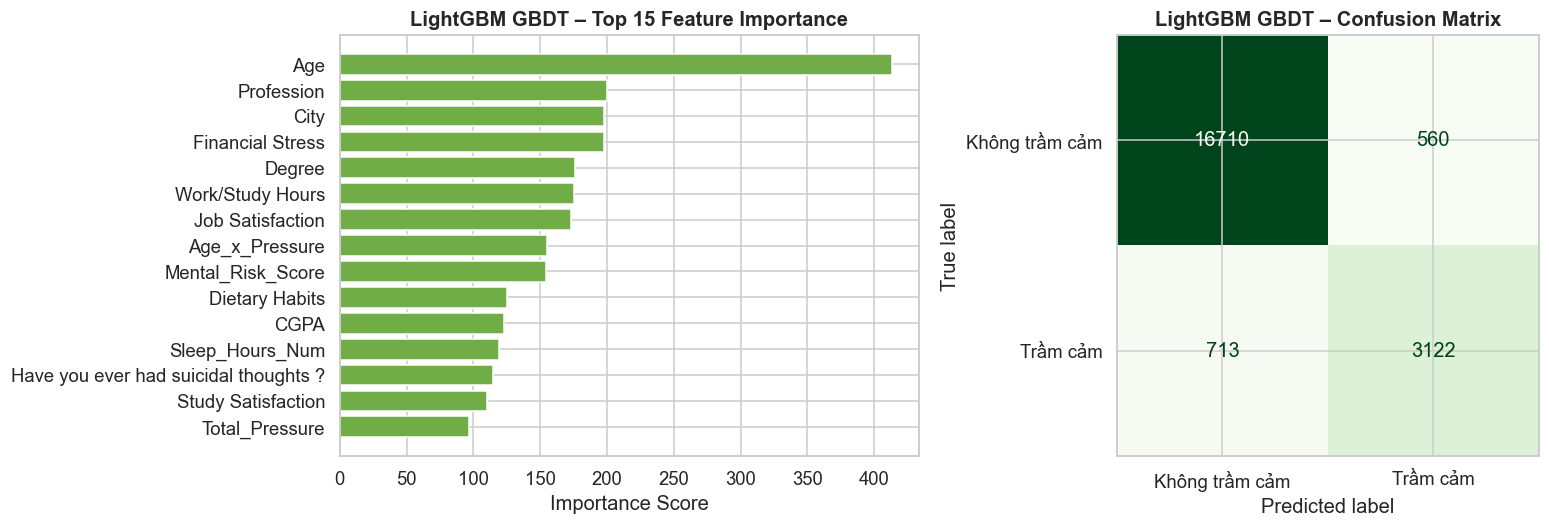


Classification Report – LightGBM GBDT:
                precision    recall  f1-score   support

Không trầm cảm       0.96      0.97      0.96     17270
      Trầm cảm       0.85      0.81      0.83      3835

      accuracy                           0.94     21105
     macro avg       0.90      0.89      0.90     21105
  weighted avg       0.94      0.94      0.94     21105



In [19]:
# Feature Importance LightGBM 
fi_lgb = pd.DataFrame({
    'Feature'   : X_tr_imp.columns,
    'Importance': best_lgb.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Feature importance
axes[0].barh(fi_lgb['Feature'][::-1], fi_lgb['Importance'][::-1], color='#70AD47')
axes[0].set_xlabel('Importance Score')
axes[0].set_title(f'LightGBM {best_boosting_type.upper()} – Top 15 Feature Importance', fontweight='bold')

# Confusion matrix
cm_lgb = confusion_matrix(y_val_final, y_pred_lgb)
ConfusionMatrixDisplay(cm_lgb, display_labels=['Không trầm cảm', 'Trầm cảm']).plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title(f'LightGBM {best_boosting_type.upper()} – Confusion Matrix', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\nClassification Report – LightGBM {best_boosting_type.upper()}:')
print(classification_report(y_val_final, y_pred_lgb, target_names=['Không trầm cảm', 'Trầm cảm']))

### Nhận xét kết quả mô hình LightGBM

- Kết quả cho thấy cả ba biến thể của LightGBM đều cho hiệu năng rất tương đồng và đều hoạt động tốt trên bài toán phân loại `Depression`. Trong đó, `GBDT` là biến thể tốt nhất với `Accuracy = 0.9386`, `ROC-AUC = 0.9742` và `F1-score = 0.8286`, nhỉnh hơn rất nhẹ so với `DART` và `GOSS`. Điều này cho thấy trên bộ dữ liệu này, LightGBM baseline đã khá ổn định và sự khác biệt giữa các biến thể không quá lớn.

- Sau bước tối ưu siêu tham số bằng Optuna, mô hình LightGBM tối ưu tiếp tục giữ biến thể `GBDT` và cải thiện nhẹ kết quả lên `Accuracy = 0.9397`, `ROC-AUC = 0.9747` và `F1-score = 0.8307`. Mức cải thiện không nhiều, cho thấy cấu hình ban đầu đã khá tốt, còn quá trình tuning chủ yếu giúp mô hình tinh chỉnh thêm để đạt hiệu quả cao hơn một chút.

- Từ `Classification Report`, mô hình dự đoán lớp `Không trầm cảm` rất tốt với `Precision = 0.96`, `Recall = 0.97` và `F1-score = 0.96`. Đối với lớp `Trầm cảm`, mô hình đạt `Precision = 0.85`, `Recall = 0.81` và `F1-score = 0.83`, cho thấy khả năng nhận diện lớp dương tính khá tốt nhưng vẫn còn bỏ sót một số trường hợp trầm cảm.

- `Confusion Matrix` cho thấy mô hình dự đoán đúng `16,710` mẫu không trầm cảm và `3,122` mẫu trầm cảm. Tuy nhiên, vẫn còn `713` trường hợp trầm cảm bị dự đoán nhầm thành không trầm cảm và `560` trường hợp không trầm cảm bị nhầm thành trầm cảm. Nhìn chung, số lỗi là không lớn so với tổng thể, nhưng với bài toán sức khỏe tinh thần thì các trường hợp bỏ sót lớp `Trầm cảm` vẫn cần được quan tâm.

- Về mức độ quan trọng của đặc trưng, `Age` là biến có ảnh hưởng mạnh nhất trong mô hình, vượt trội so với các đặc trưng còn lại. Sau đó là các biến như `Profession`, `City`, `Financial Stress`, `Degree`, `Work/Study Hours`, `Job Satisfaction`, `Mental_Risk_Score` và `Total_Pressure`. Điều này cho thấy LightGBM khai thác tốt cả đặc trưng gốc lẫn đặc trưng mới được tạo ra trong bước feature engineering.

Nhìn chung, LightGBM là một trong những mô hình mạnh nhất trong thí nghiệm, cho kết quả rất cao và ổn định. Trong ba biến thể, `GBDT` là lựa chọn phù hợp nhất cho bài toán này vì vừa cho hiệu năng tốt nhất, vừa có thời gian huấn luyện hợp lý hơn so với `DART`.

---
# **PHẦN 6 – ROC CURVE SO SÁNH TẤT CẢ CÁC MÔ HÌNH**

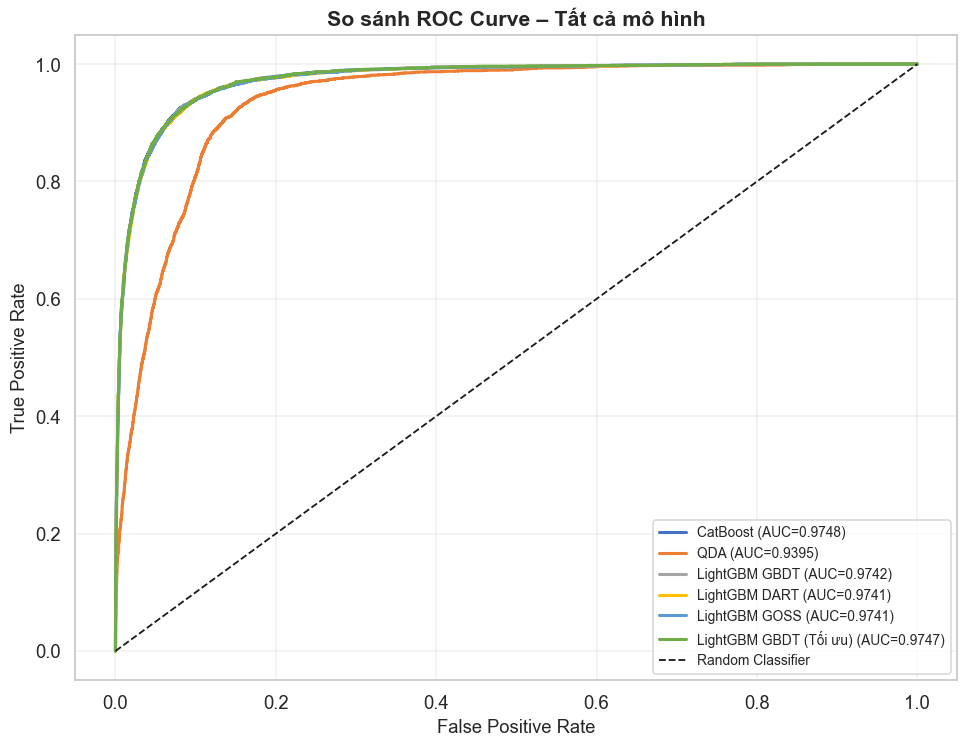

In [20]:
#  Tập hợp tất cả xác suất dự đoán 
model_probs = {
    'CatBoost'                              : y_prob_cb,
    'QDA'                                   : y_prob_qda,
    'LightGBM GBDT'                         : y_prob_gbdt,
    'LightGBM DART'                         : y_prob_dart,
    'LightGBM GOSS'                         : y_prob_goss,
    f'LightGBM {best_boosting_type.upper()} (Tối ưu)': y_prob_lgb,
}

colors_roc = ['#4472C4', '#ED7D31', '#A5A5A5', '#FFC000', '#5B9BD5', '#70AD47', '#FF0000']

fig, ax = plt.subplots(figsize=(9, 7))
for (name, probs), color in zip(model_probs.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_val_final, probs)
    auc_val = roc_auc_score(y_val_final, probs)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.4f})', color=color, lw=2)

ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('So sánh ROC Curve – Tất cả mô hình', fontsize=14, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Nhận xét biểu đồ ROC Curve

Biểu đồ ROC cho thấy hầu hết các mô hình đều có đường cong nằm rất xa đường chéo của bộ phân loại ngẫu nhiên, chứng tỏ các mô hình có khả năng phân biệt hai lớp `Trầm cảm` và `Không trầm cảm` khá tốt.

Trong các mô hình, **CatBoost** cho kết quả tốt nhất với `AUC = 0.9748`, nhỉnh hơn rất nhẹ so với **LightGBM GBDT tối ưu** (`AUC = 0.9747`) và các biến thể LightGBM còn lại (`AUC ≈ 0.9741 - 0.9742`). Điều này cho thấy nhóm mô hình boosting đều hoạt động rất mạnh và cho hiệu năng gần như tương đương nhau trên bộ dữ liệu này.

Ngược lại, **QDA** có `AUC = 0.9395`, thấp hơn rõ rệt so với các mô hình còn lại. Mặc dù đây vẫn là mức AUC khá tốt, nhưng đường ROC của QDA nằm thấp hơn ở hầu hết các vùng ngưỡng, cho thấy khả năng tách hai lớp yếu hơn so với CatBoost và LightGBM.

Nhìn chung, kết quả ROC Curve khẳng định rằng các mô hình boosting, đặc biệt là **CatBoost** và **LightGBM**, là những lựa chọn phù hợp nhất cho bài toán phân loại `Depression`, trong khi **QDA** phù hợp hơn với vai trò mô hình so sánh hoặc baseline.

---
# **PHẦN 7 – TỔNG KẾT & SO SÁNH CÁC MÔ HÌNH**

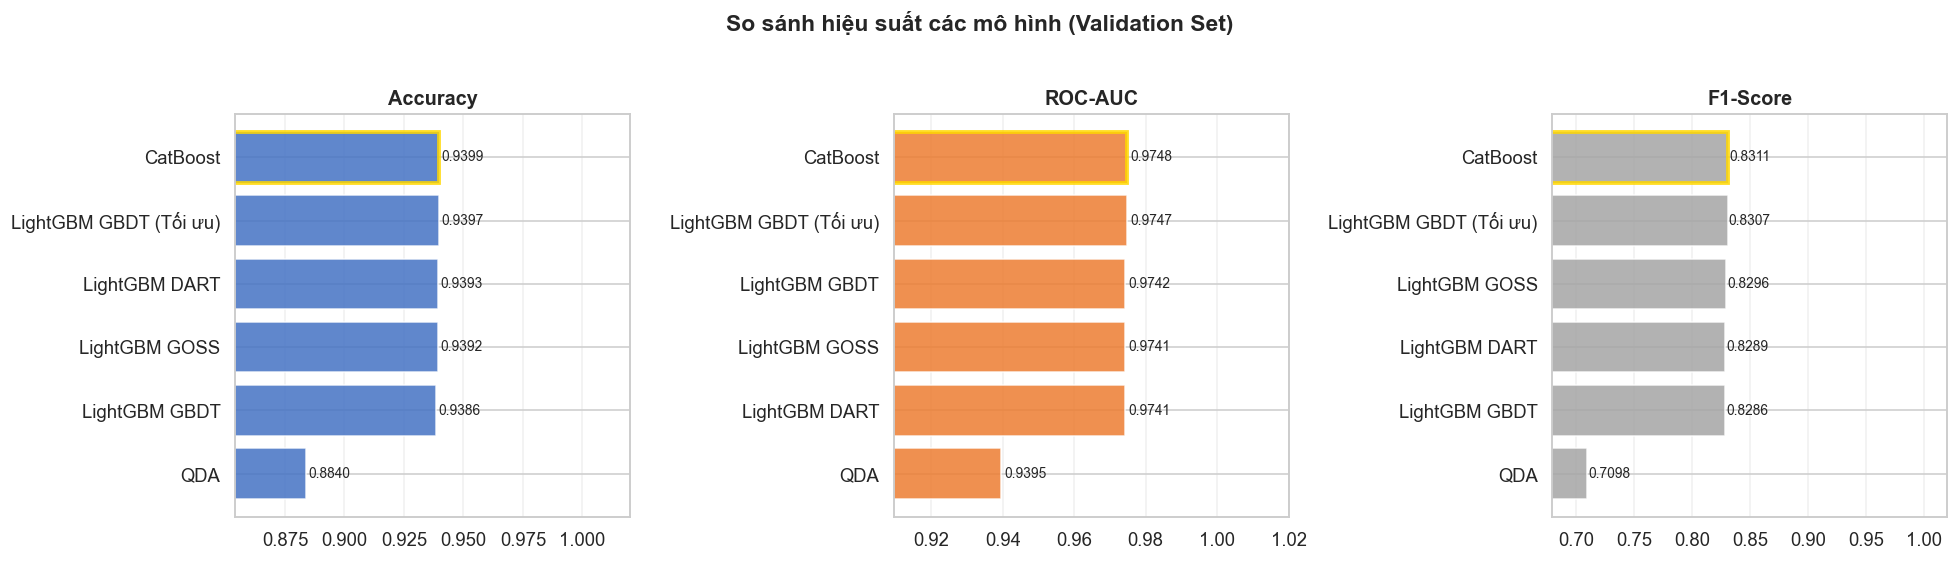

In [22]:
results_df = pd.DataFrame(results_summary).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
results_df.index += 1   # bắt đầu từ 1
# Biểu đồ so sánh trực quan 
metrics = ['Accuracy', 'ROC-AUC', 'F1-Score']
colors_bar = ['#4472C4', '#ED7D31', '#A5A5A5']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric, color in zip(axes, metrics, colors_bar):
    df_plot = results_df.sort_values(metric, ascending=True)
    bars = ax.barh(df_plot['Mô hình'], df_plot[metric], color=color, alpha=0.85, edgecolor='white')
    # Highlight cột tốt nhất
    best_idx = df_plot[metric].argmax()
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(2.5)

    for bar, val in zip(bars, df_plot[metric]):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', ha='left', fontsize=9)

    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xlim([df_plot[metric].min() - 0.03, 1.02])
    ax.set_xlabel('')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('So sánh hiệu suất các mô hình (Validation Set)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Nhận xét biểu đồ so sánh hiệu suất các mô hình

Biểu đồ cho thấy các mô hình **CatBoost** và **LightGBM** đều đạt kết quả rất cao và chênh lệch không nhiều trên cả ba chỉ số `Accuracy`, `ROC-AUC` và `F1-Score`. Trong đó, **CatBoost** là mô hình tốt nhất với `Accuracy = 0.9399`, `ROC-AUC = 0.9748` và `F1-Score = 0.8311`.

Nhóm mô hình **LightGBM** cũng cho hiệu năng rất sát nhau. Phiên bản **LightGBM GBDT tối ưu** đứng ngay sau CatBoost với `Accuracy = 0.9397`, `ROC-AUC = 0.9747` và `F1-Score = 0.8307`, cho thấy bước tối ưu siêu tham số có cải thiện nhưng không quá lớn. Hai biến thể `DART` và `GOSS` cũng cho kết quả gần tương đương, chứng tỏ LightGBM hoạt động khá ổn định trên bộ dữ liệu này.

Ngược lại, **QDA** có kết quả thấp hơn rõ rệt, đặc biệt ở chỉ số `F1-Score = 0.7098`. Điều này cho thấy QDA vẫn phân loại được dữ liệu ở mức khá, nhưng kém hiệu quả hơn so với các mô hình boosting, nhất là trong việc cân bằng giữa precision và recall cho lớp `Trầm cảm`.

Nhìn chung, biểu đồ khẳng định rằng **CatBoost** và **LightGBM** là hai lựa chọn phù hợp nhất cho bài toán phân loại `Depression`, trong khi **QDA** phù hợp hơn với vai trò mô hình đối chứng hoặc baseline.

---
# **PHẦN 8 – DỰ ĐOÁN TRÊN TẬP TEST**

In [25]:
# Chọn mô hình tốt nhất để sinh file submission 
model_map = {
    'CatBoost'                                       : (best_cb,   X_test_imp,    'raw'),
    'QDA'                                            : (best_qda,  X_test_pca,    'pca'),
    'LightGBM GBDT'                                  : (lgb_gbdt,  X_test_imp,    'raw'),
    'LightGBM DART'                                  : (lgb_dart,  X_test_imp,    'raw'),
    'LightGBM GOSS'                                  : (lgb_goss,  X_test_imp,    'raw'),
    f'LightGBM {best_boosting_type.upper()} (Tối ưu)': (best_lgb,  X_test_imp,    'raw'),
}

best_model_name = results_df.loc[results_df['ROC-AUC'].idxmax(), 'Mô hình']
best_model_obj, best_X_test, _ = model_map[best_model_name]

# Sinh dự đoán
y_test_pred = best_model_obj.predict(best_X_test)

# Đọc file submission mẫu
sub = pd.read_csv('data/sample_submission.csv') if os.path.exists('data/sample_submission.csv') \
      else pd.DataFrame({'id': test_full['id'] if 'id' in test_full.columns else range(len(y_test_pred))})

sub['Depression'] = y_test_pred.astype(int)

# Lưu file
os.makedirs('data/submissions', exist_ok=True)
sub_path = f'data/submissions/submission_{best_model_name.replace(" ", "_")}.csv'
sub.to_csv(sub_path, index=False)

print(f'   Đã lưu file submission: {sub_path}')
print(f'   Tỷ lệ dự đoán trầm cảm: {sub["Depression"].mean():.2%}')
print()

   Đã lưu file submission: data/submissions/submission_CatBoost.csv
   Tỷ lệ dự đoán trầm cảm: 17.53%

